# Проект: scoring аномалий тайм-трекинга

В предыдущих ноутбуках были:

- сформулирована бизнес-задача;
- проведён EDA;
- найдено, что `mgmt/time` лежит в `project_path`, а не в `task`;
- выяснено, что выходные сами по себе не являются надёжным сигналом;
- собран proxy-target для недель с повышенным риском ручной проверки;
- опробованы baseline-модели, ансамбль и SHAP-интерпретация.

В этом ноутбуке всё собирается в единый финальный пайплайн: нормализованные признаки, временное разбиение, бейзлайн, более сложная модель, подбор гиперпараметров, оценка, интерпретация и итоговый scoring.

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import shap

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
F2_SCORER = make_scorer(fbeta_score, beta=2, zero_division=0)

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

/Users/vadimmikhu/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### NDA

In [2]:
from IPython.display import display

MASK_COLUMNS = {"project_path", "task", "user", "name", "comment"}

_original_repr_html = pd.DataFrame._repr_html_

def _masked_repr_html(self):
    df = self.copy()

    for col in MASK_COLUMNS & set(df.columns):
        df[col] = "***"

    return _original_repr_html(df)

pd.DataFrame._repr_html_ = _masked_repr_html

## 1. Загрузка исходного датасета и единая предобработка

Здесь используется тот же исходный timesheet-файл, что и в предыдущих ноутбуках. Подход к парсингу остаётся тем же: `date`, `hours`, `duration`, `comment` и `project_path` приводятся к удобному виду.

In [3]:
PATH = Path("timelogs.csv")
df = pd.read_csv(PATH, sep=";", encoding="utf-8-sig")

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

rename_map = {
    "проект": "project",
    "путь_проекта": "project_path",
    "задача": "task",
    "пользователь": "user",
    "имя": "name",
    "дата": "date",
    "часы": "hours",
    "продолжительность": "duration",
    "комментарий": "comment",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

text_cols = [c for c in ["project", "project_path", "task", "user", "name", "comment"] if c in df.columns]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["hours"] = (
    df["hours"]
    .astype("string")
    .str.replace(",", ".", regex=False)
)
df["hours"] = pd.to_numeric(df["hours"], errors="coerce")

def parse_duration_to_hours(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()
    if s in {"", "nan", "none", "null"}:
        return np.nan

    if ":" in s:
        parts = s.split(":")
        try:
            parts = [float(p) for p in parts]
        except ValueError:
            return np.nan

        if len(parts) == 3:
            hours, minutes, seconds = parts
            return hours + minutes / 60 + seconds / 3600
        if len(parts) == 2:
            hours, minutes = parts
            return hours + minutes / 60
        return np.nan

    hours_match = re.search(r"(\d+(?:\.\d+)?)\s*h", s)
    minutes_match = re.search(r"(\d+(?:\.\d+)?)\s*m", s)

    if hours_match or minutes_match:
        hours = float(hours_match.group(1)) if hours_match else 0.0
        minutes = float(minutes_match.group(1)) if minutes_match else 0.0
        return hours + minutes / 60

    num_match = re.search(r"(\d+(?:\.\d+)?)", s)
    if num_match:
        return float(num_match.group(1))

    return np.nan

df["duration_hours"] = (
    df["duration"].apply(parse_duration_to_hours)
    if "duration" in df.columns
    else np.nan
)

df["is_general_time"] = (
    df["project_path"].astype("string").str.lower().eq("mgmt/time")
)

df["weekday_num"] = df["date"].dt.dayofweek
df["is_weekend"] = df["weekday_num"] >= 5
df["calendar_date"] = df["date"].dt.date
df["week_start"] = df["date"].dt.to_period("W-MON").dt.start_time

df["comment"] = df["comment"].fillna("")
df["comment_len"] = df["comment"].astype(str).str.len()
df["comment_is_empty"] = df["comment"].astype(str).str.strip().eq("")

df = df[df["date"].notna() & df["hours"].notna()].copy()

print("Shape after cleaning:", df.shape)
display(df.head(3))

Shape after cleaning: (12866, 17)


,project,project_path,task,user,name,date,hours,duration,comment,duration_hours,is_general_time,weekday_num,is_weekend,calendar_date,week_start,comment_len,comment_is_empty
0,Time Management,***,***,***,***,2026-05-06 12:51:00,0.5,30m,***,0.5,True,2,False,2026-05-06,2026-05-05,41,False
1,Time Management,***,***,***,***,2026-05-06 12:50:00,0.5,30m,***,0.5,True,2,False,2026-05-06,2026-05-05,36,False
2,Time Management,***,***,***,***,2026-05-06 12:36:00,0.5,30m,***,0.5,True,2,False,2026-05-06,2026-05-05,181,False


## 2. Сборка недельных признаков

Одна строка соответствует `user-week`.

Для финальной модели полезно использовать не только абсолютные значения, но и нормализованные признаки: число записей на активный день, часы на запись, доли общего времени и концентрацию по задачам.

In [4]:
df["long_track"] = (df["hours"] >= 3).astype(int)

weekly = (
    df.groupby(["user", "name", "week_start"], as_index=False)
    .agg(
        total_hours=("hours", "sum"),
        tracks=("hours", "size"),
        active_days=("calendar_date", "nunique"),
        unique_projects=("project", "nunique"),
        unique_tasks=("task", "nunique"),
        weekend_tracks=("is_weekend", "sum"),
        weekend_hours=("hours", lambda s: s[df.loc[s.index, "is_weekend"]].sum()),
        empty_comment_share=("comment_is_empty", "mean"),
        avg_comment_len=("comment_len", "mean"),
        general_tracks=("is_general_time", "sum"),
        general_hours=("hours", lambda s: s[df.loc[s.index, "is_general_time"]].sum()),
        avg_hours_per_track=("hours", "mean"),
        median_hours_per_track=("hours", "median"),
        max_hours_per_track=("hours", "max"),
        long_track_share=("long_track", "mean"),
    )
)

task_hours = (
    df.groupby(["user", "week_start", "task"], as_index=False)["hours"]
    .sum()
)
top_task = (
    task_hours.sort_values(["user", "week_start", "hours"], ascending=[True, True, False])
    .groupby(["user", "week_start"], as_index=False)
    .head(1)[["user", "week_start", "hours"]]
    .rename(columns={"hours": "top_task_hours"})
)

project_hours = (
    df.groupby(["user", "week_start", "project"], as_index=False)["hours"]
    .sum()
)
top_project = (
    project_hours.sort_values(["user", "week_start", "hours"], ascending=[True, True, False])
    .groupby(["user", "week_start"], as_index=False)
    .head(1)[["user", "week_start", "hours"]]
    .rename(columns={"hours": "top_project_hours"})
)

weekly = weekly.merge(top_task, on=["user", "week_start"], how="left")
weekly = weekly.merge(top_project, on=["user", "week_start"], how="left")

weekly["general_share"] = weekly["general_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["weekend_share"] = weekly["weekend_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["top_task_share"] = weekly["top_task_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["top_project_share"] = weekly["top_project_hours"] / weekly["total_hours"].replace(0, np.nan)

weekly["general_share"] = weekly["general_share"].fillna(0)
weekly["weekend_share"] = weekly["weekend_share"].fillna(0)
weekly["top_task_share"] = weekly["top_task_share"].fillna(0).clip(0, 1)
weekly["top_project_share"] = weekly["top_project_share"].fillna(0).clip(0, 1)
weekly["long_track_share"] = weekly["long_track_share"].fillna(0)
weekly["active_days"] = weekly["active_days"].fillna(0)

weekly["hours_per_track"] = weekly["total_hours"] / weekly["tracks"].replace(0, np.nan)
weekly["hours_per_active_day"] = weekly["total_hours"] / weekly["active_days"].replace(0, np.nan)
weekly["tracks_per_active_day"] = weekly["tracks"] / weekly["active_days"].replace(0, np.nan)
weekly["tasks_per_active_day"] = weekly["unique_tasks"] / weekly["active_days"].replace(0, np.nan)
weekly["projects_per_active_day"] = weekly["unique_projects"] / weekly["active_days"].replace(0, np.nan)

weekly = weekly.replace([np.inf, -np.inf], np.nan)
weekly = weekly.dropna(subset=["hours_per_track", "hours_per_active_day", "tracks_per_active_day"]).copy()

print("Weekly shape:", weekly.shape)
display(weekly.head(3))

Weekly shape: (1135, 29)


,user,name,week_start,total_hours,tracks,active_days,unique_projects,unique_tasks,weekend_tracks,weekend_hours,...,top_project_hours,general_share,weekend_share,top_task_share,top_project_share,hours_per_track,hours_per_active_day,tracks_per_active_day,tasks_per_active_day,projects_per_active_day
0,***,***,2025-08-26,40.0,1,1,1,1,0,0.0,...,40.0,1.0,0.0,1.0,1.0,40.0,40.0,1.0,1.0,1.0
1,***,***,2025-09-09,6.0,3,2,1,3,0,0.0,...,6.0,0.0,0.0,0.5,1.0,2.0,3.0,1.5,1.5,0.5
2,***,***,2025-09-16,1.0,1,1,1,1,0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. Proxy-target и фильтрация слишком маленьких недель

В предыдущем ноутбуке было показано, что слишком маленькие недели дают искусственно высокий риск. Здесь мы оставляем только достаточно информативные недели, чтобы модель училась на реальной структуре трекинга.

In [5]:
def zscore(series):
    series = series.astype(float)
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

weekly["risk_score_rule"] = (
    0.20 * zscore(weekly["long_track_share"]) +
    0.20 * zscore(weekly["top_task_share"]) +
    0.15 * zscore(weekly["top_project_share"]) +
    0.15 * zscore(weekly["empty_comment_share"]) +
    0.10 * zscore(weekly["general_share"]) +
    0.10 * zscore(weekly["weekend_share"]) +
    0.10 * zscore(weekly["tracks_per_active_day"])
)

weekly = weekly[(weekly["tracks"] >= 3) & (weekly["active_days"] >= 2)].copy()

threshold = weekly["risk_score_rule"].quantile(0.85)
weekly["risk_week"] = (weekly["risk_score_rule"] >= threshold).astype(int)

print("Threshold:", round(float(threshold), 4))
display(
    weekly["risk_week"]
    .value_counts()
    .rename(index={0: "normal week", 1: "manual review week"})
)

Threshold: 0.365


risk_week
normal week           793
manual review week    140
Name: count, dtype: int64

## 4. Разбиение на train/test по времени

Для бизнес-сценария важнее тестировать на будущих неделях, а не случайно перемешивать прошлое и будущее.

In [6]:
feature_cols = [
    "total_hours",
    "tracks",
    "active_days",
    "unique_projects",
    "unique_tasks",
    "weekend_tracks",
    "weekend_hours",
    "empty_comment_share",
    "avg_comment_len",
    "general_tracks",
    "general_hours",
    "general_share",
    "weekend_share",
    "top_task_share",
    "top_project_share",
    "long_track_share",
    "avg_hours_per_track",
    "median_hours_per_track",
    "max_hours_per_track",
    "hours_per_track",
    "hours_per_active_day",
    "tracks_per_active_day",
    "tasks_per_active_day",
    "projects_per_active_day",
]

weekly = weekly.sort_values("week_start").copy()

unique_weeks = np.array(sorted(weekly["week_start"].unique()))
test_fraction_candidates = [0.20, 0.25, 0.30, 0.35]
split_found = False

for test_fraction in test_fraction_candidates:
    test_weeks = max(1, int(np.ceil(len(unique_weeks) * test_fraction)))
    cutoff = unique_weeks[-test_weeks]

    train_mask = weekly["week_start"] < cutoff
    test_mask = weekly["week_start"] >= cutoff

    if (
        weekly.loc[train_mask, "risk_week"].nunique() >= 2
        and weekly.loc[test_mask, "risk_week"].nunique() >= 2
    ):
        split_found = True
        break

if not split_found:
    cutoff = unique_weeks[int(len(unique_weeks) * 0.8)]
    train_mask = weekly["week_start"] < cutoff
    test_mask = weekly["week_start"] >= cutoff

X_train = weekly.loc[train_mask, feature_cols].copy()
X_test = weekly.loc[test_mask, feature_cols].copy()
y_train = weekly.loc[train_mask, "risk_week"].copy()
y_test = weekly.loc[test_mask, "risk_week"].copy()

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train balance:")
display(y_train.value_counts(normalize=True))
print("Test balance:")
display(y_test.value_counts(normalize=True))

Train: (744, 24)  Test: (189, 24)
Train balance:


risk_week
0    0.862903
1    0.137097
Name: proportion, dtype: float64

Test balance:


risk_week
0    0.798942
1    0.201058
Name: proportion, dtype: float64

## 5. Метрики и оценка бейзлайна

Основная метрика остаётся **F2-score**: в этой задаче пропуск подозрительной недели дороже, чем лишняя ручная проверка.

Дополнительно показываем precision, recall, ROC-AUC и PR-AUC для более полного понимания поведения модели.

In [7]:
def evaluate_predictions(y_true, y_pred, y_proba, name):
    return {
        "model": name,
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan,
    }


def predict_with_threshold(model, X, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return pred, proba

In [8]:
dummy = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_pred, dummy_proba = predict_with_threshold(dummy, X_test, threshold=0.5)
dummy_result = evaluate_predictions(y_test, dummy_pred, dummy_proba, "Dummy prior")

display(pd.DataFrame([dummy_result]))

,model,f2,precision,recall,roc_auc,pr_auc
0,Dummy prior,0.0,0.0,0.0,0.5,0.201058


## 6. Простой baseline: логистическая регрессия

Для логистической регрессии нужны медианная имputation и стандартизация признаков. Это хороший интерпретируемый baseline для табличных данных.

In [9]:
logreg_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logreg_pipe.fit(X_train, y_train)
logreg_pred, logreg_proba = predict_with_threshold(logreg_pipe, X_test, threshold=0.5)
logreg_result = evaluate_predictions(y_test, logreg_pred, logreg_proba, "LogReg baseline")

results_baseline = pd.DataFrame([dummy_result, logreg_result]).sort_values("f2", ascending=False)
display(results_baseline)

,model,f2,precision,recall,roc_auc,pr_auc
1,LogReg baseline,0.974359,0.883721,1.0,0.998606,0.994607
0,Dummy prior,0.000000,0.000000,0.0,0.500000,0.201058


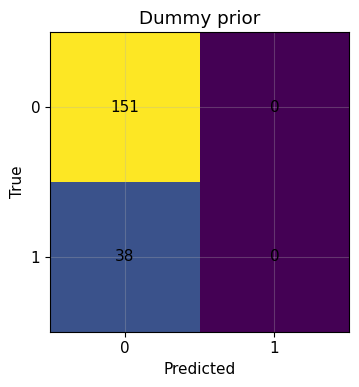

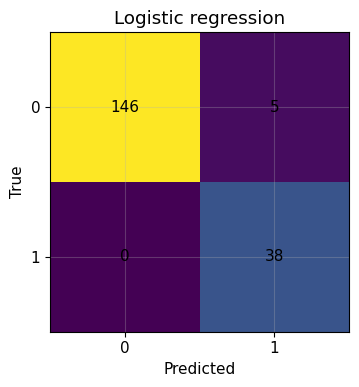

In [10]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, dummy_pred, "Dummy prior")
plot_confusion(y_test, logreg_pred, "Logistic regression")

## 7. Более сложная модель: RandomForest с подбором гиперпараметров

Лес деревьев хорошо подходит для нелинейных взаимодействий и не требует масштабирования признаков.

Подбор гиперпараметров выполняется на кросс-валидации по обучающей части, без использования теста.

In [11]:
rf_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample",
                n_jobs=-1,
            ),
        ),
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.7],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_distributions,
    n_iter=15,
    scoring=F2_SCORER,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train)

print("Best CV F2:", round(search.best_score_, 4))
print("Best params:")
print(search.best_params_)

Best CV F2: 0.7349
Best params:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 6}


,model,f2,precision,recall,roc_auc,pr_auc
1,LogReg baseline,0.974359,0.883721,1.000000,0.998606,0.994607
2,RandomForest tuned,0.913706,0.800000,0.947368,0.982224,0.915531
0,Dummy prior,0.000000,0.000000,0.000000,0.500000,0.201058


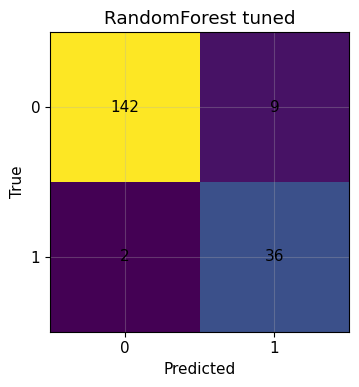

In [12]:
best_rf = search.best_estimator_
rf_pred, rf_proba = predict_with_threshold(best_rf, X_test, threshold=0.5)
rf_result = evaluate_predictions(y_test, rf_pred, rf_proba, "RandomForest tuned")

results_model = pd.DataFrame([dummy_result, logreg_result, rf_result]).sort_values("f2", ascending=False)
display(results_model)

plot_confusion(y_test, rf_pred, "RandomForest tuned")

## 8. Подбор рабочего порога для риск-скоринга

В production вероятность удобно переводить в рабочий порог, чтобы получить бинарную метку “на ручную проверку / не на ручную проверку”.

Ниже порог выбирается по обучающей выборке так, чтобы максимизировать F2.

In [13]:
threshold_grid = np.linspace(0.05, 0.95, 91)
train_proba_cv = np.zeros(len(X_train))

for train_idx, valid_idx in cv.split(X_train, y_train):
    fold_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    fold_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    **fold_params,
                ),
            ),
        ]
    )
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    train_proba_cv[valid_idx] = fold_model.predict_proba(X_train.iloc[valid_idx])[:, 1]

f2_scores = []
for thr in threshold_grid:
    pred_thr = (train_proba_cv >= thr).astype(int)
    f2_scores.append(fbeta_score(y_train, pred_thr, beta=2, zero_division=0))

best_threshold = float(threshold_grid[int(np.argmax(f2_scores))])
print("Best threshold on train CV:", round(best_threshold, 3))
print("Best CV F2 at threshold:", round(float(np.max(f2_scores)), 4))

Best threshold on train CV: 0.17
Best CV F2 at threshold: 0.8198


,model,f2,precision,recall,roc_auc,pr_auc,threshold
0,RandomForest tuned @thr=0.17,0.875576,0.584615,1.0,0.982224,0.915531,0.17


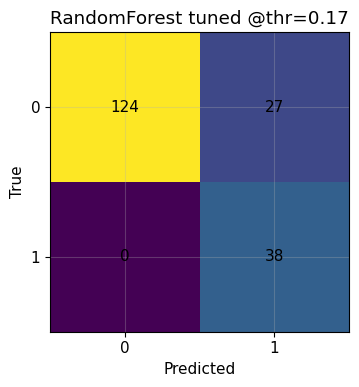

In [14]:
test_pred_best_thr = (rf_proba >= best_threshold).astype(int)
rf_result_best_thr = evaluate_predictions(
    y_test,
    test_pred_best_thr,
    rf_proba,
    f"RandomForest tuned @thr={best_threshold:.2f}",
)

display(pd.DataFrame([rf_result_best_thr]).assign(threshold=best_threshold))
plot_confusion(y_test, test_pred_best_thr, f"RandomForest tuned @thr={best_threshold:.2f}")

## 9. Итоговый риск-скор

Вероятности модели используются как риск-скор. Для прикладного использования дополнительно задаются уровни риска.

In [15]:
weekly_scored = weekly.loc[test_mask].copy()
weekly_scored["risk_score"] = rf_proba
weekly_scored["risk_pred"] = test_pred_best_thr

def risk_level(p):
    if p >= 0.82:
        return "high"
    if p >= 0.35:
        return "medium"
    if p >= 0.17:
        return "low"
    return "normal"

weekly_scored["risk_level"] = weekly_scored["risk_score"].apply(risk_level)

display(
    weekly_scored.sort_values("risk_score", ascending=False)
    .head(15)[
        [
            "user", "week_start", "risk_score", "risk_level",
            "tracks", "active_days", "general_share", "top_task_share",
            "top_project_share", "long_track_share", "empty_comment_share"
        ]
    ]
)

,user,week_start,risk_score,risk_level,tracks,active_days,general_share,top_task_share,top_project_share,long_track_share,empty_comment_share
695,***,2026-04-21,0.990084,high,5,5,1.0,0.8,1.0,1.000000,0.0
696,***,2026-04-28,0.976158,high,4,4,1.0,0.75,1.0,1.000000,0.0
423,***,2026-03-31,0.963598,high,5,5,1.0,0.842105,1.0,1.000000,0.0
628,***,2026-03-17,0.963289,high,9,5,1.0,0.780822,1.0,0.666667,0.0
422,***,2026-03-24,0.962930,high,4,4,1.0,1.0,1.0,1.000000,0.0
691,***,2026-03-24,0.935620,high,8,4,1.0,0.938776,1.0,0.375000,0.0
831,***,2026-03-17,0.875300,high,12,5,0.971831,0.830986,0.971831,0.500000,0.0
862,***,2026-03-24,0.869836,high,9,5,0.963631,0.792664,0.963631,0.555556,0.0
694,***,2026-04-14,0.851202,high,9,4,1.0,0.942485,1.0,0.333333,0.0
864,***,2026-04-07,0.826660,high,7,5,0.875,0.75,0.875,1.000000,0.0


## 10. Глобальная интерпретация модели

Сначала смотрим permutation importance на отложенной выборке. Это показывает, какие признаки действительно важны для качества модели на тесте.

,feature,importance_mean,importance_std
13,top_task_share,0.510731,0.080810
11,general_share,0.275299,0.047296
15,long_track_share,0.214352,0.037178
12,weekend_share,0.130343,0.021181
14,top_project_share,0.099227,0.032579
6,weekend_hours,0.045811,0.013896
3,unique_projects,0.008106,0.010452
1,tracks,0.007507,0.009549
4,unique_tasks,0.004979,0.009217
21,tracks_per_active_day,0.004201,0.014084


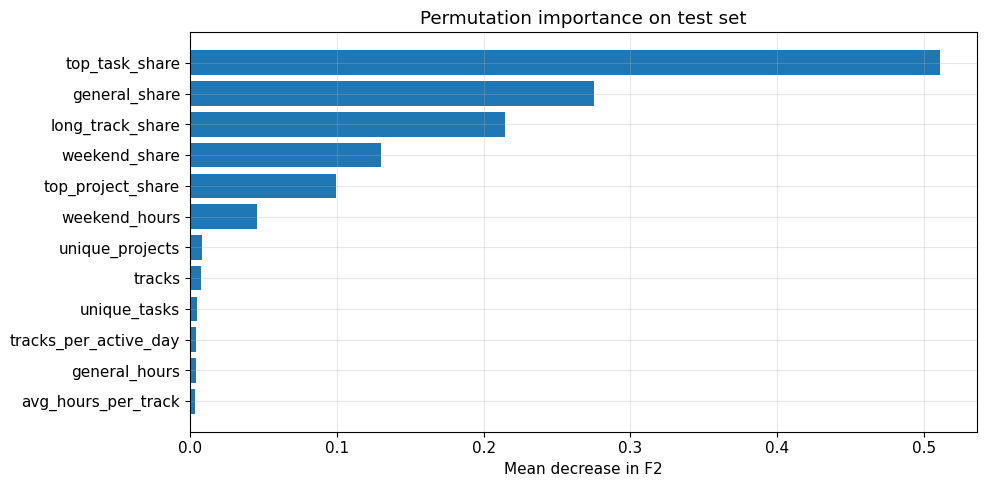

In [16]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring=F2_SCORER,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
)

display(perm_df.head(12))

plot_df = perm_df.head(12).sort_values("importance_mean")
plt.figure(figsize=(10, 5))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title("Permutation importance on test set")
plt.xlabel("Mean decrease in F2")
plt.tight_layout()
plt.show()

## 11. SHAP-интерпретация

Для дерева решений используем SHAP TreeExplainer. Это даёт глобальную картину влияния признаков и локальное объяснение отдельных недель.

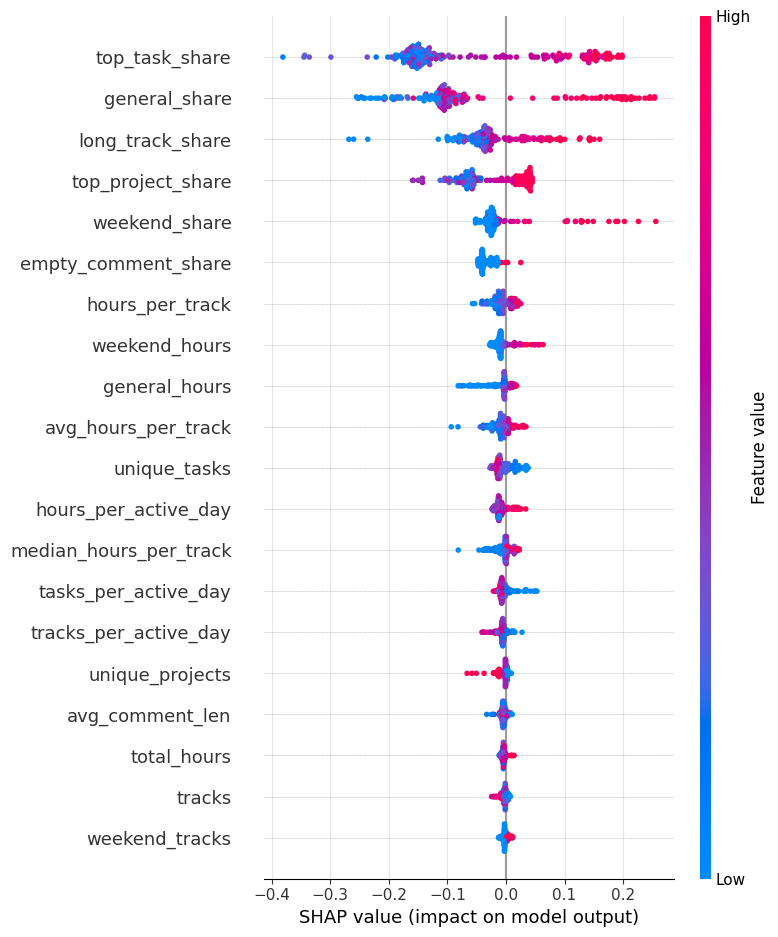

In [17]:
X_test_imp = pd.DataFrame(
    best_rf.named_steps["imputer"].transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

rf_model = best_rf.named_steps["model"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_imp)

if isinstance(shap_values, list):
    shap_for_class_1 = shap_values[1]
else:
    shap_for_class_1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

shap.summary_plot(shap_for_class_1, X_test_imp, show=True)

High-risk example
True label: 1
Predicted probability: 0.9901


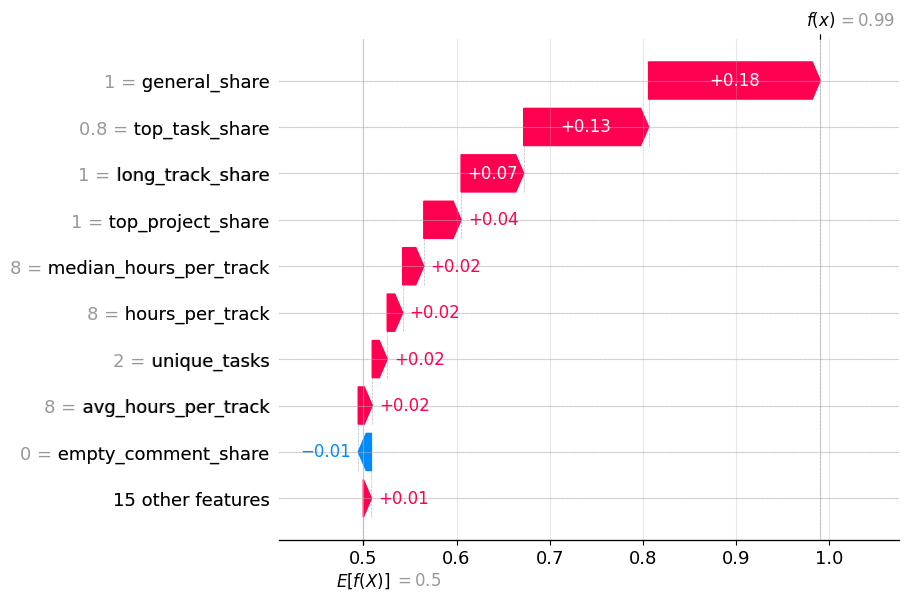

Low-risk example
True label: 0
Predicted probability: 0.0


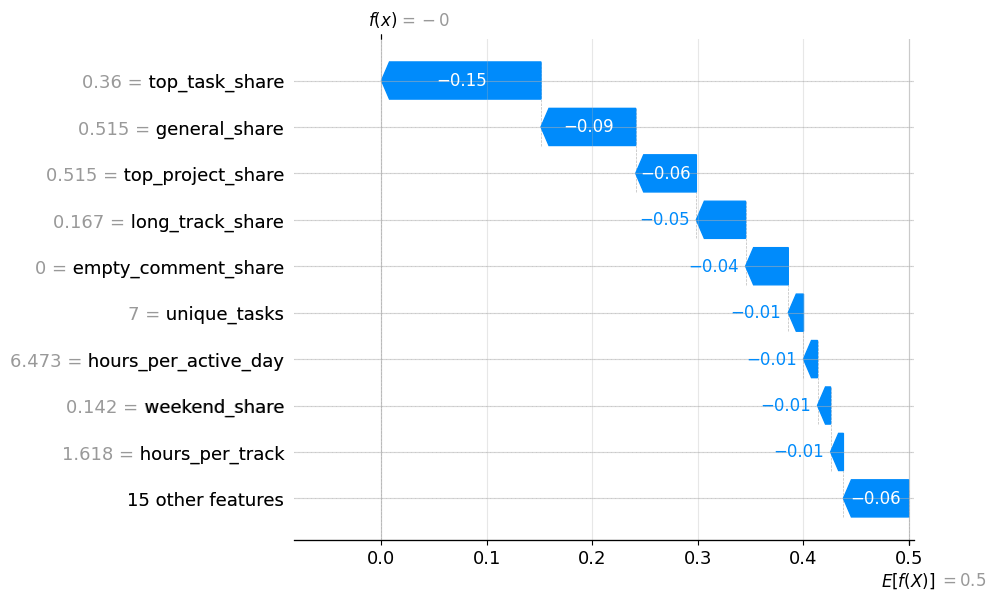

In [18]:
def make_single_explanation(explainer_obj, row_df, class_index=1):
    shap_row = explainer_obj.shap_values(row_df)

    if isinstance(shap_row, list):
        values = shap_row[class_index][0]
        base_value = explainer_obj.expected_value[class_index]
    elif hasattr(shap_row, "ndim") and shap_row.ndim == 3:
        values = shap_row[0, :, class_index]
        base_value = explainer_obj.expected_value[class_index]
    else:
        values = shap_row[0]
        base_value = explainer_obj.expected_value

    return shap.Explanation(
        values=values,
        base_values=base_value,
        data=row_df.iloc[0].values,
        feature_names=row_df.columns.tolist(),
    )

local_df = X_test.copy()
local_df["y_true"] = y_test.values
local_df["y_pred_proba"] = rf_proba
local_df = local_df.sort_values("y_pred_proba", ascending=False)

high_idx = local_df.index[0]
low_idx = local_df.index[-1]

for idx, title in [
    (high_idx, "High-risk example"),
    (low_idx, "Low-risk example"),
]:
    row = X_test_imp.loc[[idx]]
    explanation = make_single_explanation(explainer, row, class_index=1)

    print("=" * 60)
    print(title)
    print("True label:", int(local_df.loc[idx, "y_true"]))
    print("Predicted probability:", round(float(local_df.loc[idx, "y_pred_proba"]), 4))

    shap.plots.waterfall(explanation, max_display=10)

## 12. Экспертная интерпретация

Модель ведёт себя разумно, если в топе оказываются:

- концентрация времени в одной задаче или проекте;
- малое число записей и активных дней;
- высокий `general_share`;
- высокий `long_track_share`;
- слабое заполнение комментариев.


## 13. Финальный scoring и экспорт

Финальный результат — таблица с риском на уровне `user-week`.

In [19]:
final_scoring = weekly_scored[
    [
        "user",
        "name",
        "week_start",
        "risk_score",
        "risk_level",
        "risk_pred",
        "tracks",
        "active_days",
        "total_hours",
        "general_share",
        "weekend_share",
        "top_task_share",
        "top_project_share",
        "long_track_share",
        "empty_comment_share",
    ]
].sort_values("risk_score", ascending=False)

display(final_scoring.head(20))

,user,name,week_start,risk_score,risk_level,risk_pred,tracks,active_days,total_hours,general_share,weekend_share,top_task_share,top_project_share,long_track_share,empty_comment_share
695,***,***,2026-04-21,0.990084,high,1,5,5,40.0,1.0,0.0,0.8,1.0,1.000000,0.0
696,***,***,2026-04-28,0.976158,high,1,4,4,32.0,1.0,0.0,0.75,1.0,1.000000,0.0
423,***,***,2026-03-31,0.963598,high,1,5,5,19.0,1.0,0.157895,0.842105,1.0,1.000000,0.0
628,***,***,2026-03-17,0.963289,high,1,9,5,36.5,1.0,0.0,0.780822,1.0,0.666667,0.0
422,***,***,2026-03-24,0.962930,high,1,4,4,16.0,1.0,0.0,1.0,1.0,1.000000,0.0
691,***,***,2026-03-24,0.935620,high,1,8,4,24.5,1.0,0.0,0.938776,1.0,0.375000,0.0
831,***,***,2026-03-17,0.875300,high,1,12,5,35.5,0.971831,0.0,0.830986,0.971831,0.500000,0.0
862,***,***,2026-03-24,0.869836,high,1,9,5,32.17,0.963631,0.0,0.792664,0.963631,0.555556,0.0
694,***,***,2026-04-14,0.851202,high,1,9,4,26.08,1.0,0.0,0.942485,1.0,0.333333,0.0
864,***,***,2026-04-07,0.826660,high,1,7,5,48.0,0.875,0.0,0.75,0.875,1.000000,0.0


## 14. Итог

В этом ноутбуке собран весь цикл проекта в рабочем виде:

- гипотеза и proxy-target были определены ранее;
- здесь используется финальный набор признаков;
- бейзлайн и ансамбль сравниваются на временном holdout;
- для ансамбля выполнен подбор гиперпараметров;
- модель интерпретируется глобально и локально;
- итогом является ранжированный scoring `user-week`.